# DATA CLEANING & PREPROCESSING

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

### Configurations

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    shuffle=True,
    image_size = IMAGE_SIZE,
    batch_size= BATCH_SIZE,
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset) # Why 68 - It is due to batch size 32, dataset contain  68, 32 size batches but last batch doesn not have 32

68

### Showing one image

In [6]:
type(dataset)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [7]:
for i in dataset.take(1):
    # print (i[0][0]) # First image
    print (i[1][0]) # First label
    print(len(i))
    print(len(i[0]))
    print(len(i[1]))

tf.Tensor(0, shape=(), dtype=int32)
2
32
32


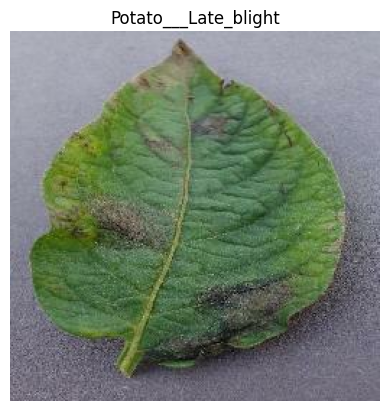

In [8]:
# dataset is collection of 68 batches each batch contain of 32 images + 32 label as seperate two lists

for img_batch, label_batch in dataset.take(1):
    # print (i[0][0]) # First image
    plt.imshow(img_batch[0].numpy().astype('uint8')) # First batch first image show
    plt.title(class_names[label_batch[0]])
    plt.axis('off')

### Showing multiple images

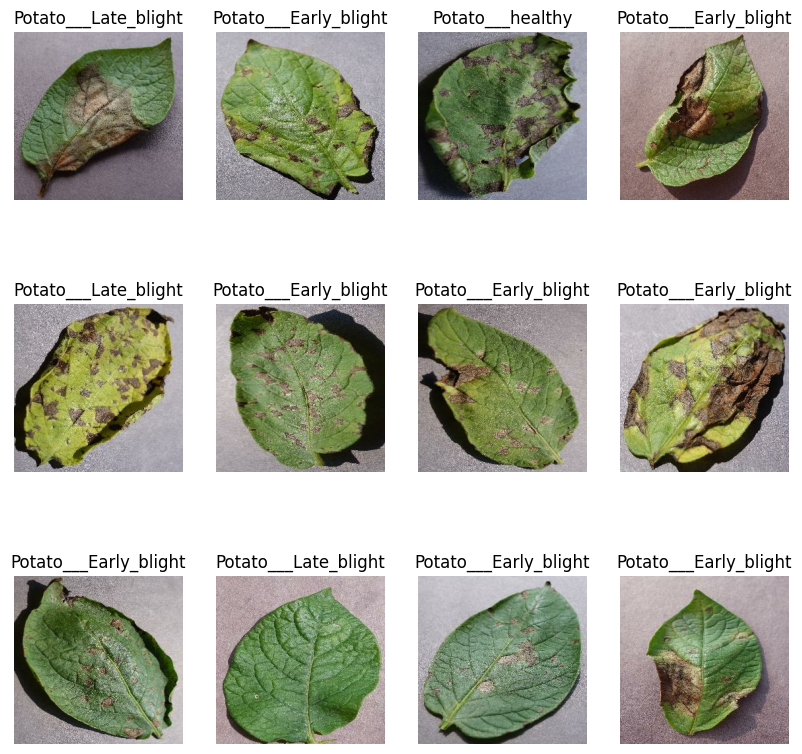

In [9]:
plt.figure(figsize=(10, 10))

for img_batch, lable_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(img_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

### Train test splitting

80% ==> training<br>
20% ==> 10% validation 10% testing

In [10]:
train_size = int(len(dataset)*0.8)
train_size

54

In [17]:
train_ds = dataset.take(train_size)
print(len(train_ds))
      
test_val_ds = dataset.skip(train_size)
print(len(test_val_ds))

54
14


In [18]:
val_size =int(len(dataset)* 0.1)
val_size

6

In [19]:
val_ds = test_val_ds.take(val_size)
len(val_ds)

6

In [20]:
test_ds = test_val_ds.skip(val_size)
len(test_ds)

8

In [11]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=123)
        
    ds_size = int(len(ds))
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)
    # rest of part for test
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [12]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


In [13]:
'''
*** cache() : Stores the dataset in memory after loading it once.
    - First epoch -> loads from disk
    - Next epochs -> uses memory (faster)

*** What is buffer size? While the model is training on Batch 1 : 
    - GPU training on Batch 1
    - CPU preparing Batch 2
    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance

*** AUTOTUNE lets TensorFlow automatically choose the best buffer size
'''

'\n*** cache() : Stores the dataset in memory after loading it once.\n    - First epoch -> loads from disk\n    - Next epochs -> uses memory (faster)\n\n*** What is buffer size? While the model is training on Batch 1 : \n    - GPU training on Batch 1\n    - CPU preparing Batch 2\n    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance\n\n*** AUTOTUNE lets TensorFlow automatically choose the best buffer size\n'

In [14]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

### Scaling, we will supply this layer when building the model

In [18]:
resize_rescale_layer = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), # ensure 256 x 256
    layers.Rescaling(1.0/255) # 0 - 1
])

### Data Augmentation
- Data augmentation is a technique used to increase the diversity of training data by applying random transformations to images
- Instead of collecting new images, we create modified versions of existing images

In [19]:
data_augmentation = tf.keras.Sequential([
    # Randomly flips images : left <-> right (horizontal) & up <-> down (vertical), Ex : Cat facing left -> flipped cat facing right
    layers.RandomFlip('horizontal_and_vertical'),

    # Randomly rotates the image -> 0.2 means up to 20% of 360 -> nearly ±72 degrees
    layers.RandomRotation(0.2)
])